In [2]:
import sys
from pathlib import Path

repo_root = Path.cwd()
while not (repo_root / "src").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

In [3]:
from blimpy import Waterfall

fil = Waterfall(str(repo_root / "data/raw/Voyager1.single_coarse.fine_res.h5"))
fil.info()


--- File Info ---
DIMENSION_LABELS :   ['frequency' 'feed_id' 'time']
        az_start :                              0.0
       data_type :                                1
            fch1 :            8421.386717353016 MHz
            foff :      -2.7939677238464355e-06 MHz
           ibeam :                                1
      machine_id :                               20
          nbeams :                                1
           nbits :                               32
          nchans :                          1048576
            nifs :                                1
     rawdatafile : guppi_57650_67573_Voyager1_0002.0000.raw
     source_name :                         Voyager1
         src_dej :                       12:10:58.8
         src_raj :                     17:10:03.984
    telescope_id :                                6
           tsamp :                     18.253611008
   tstart (ISOT) :          2016-09-19T18:46:13.000
    tstart (MJD) :                576

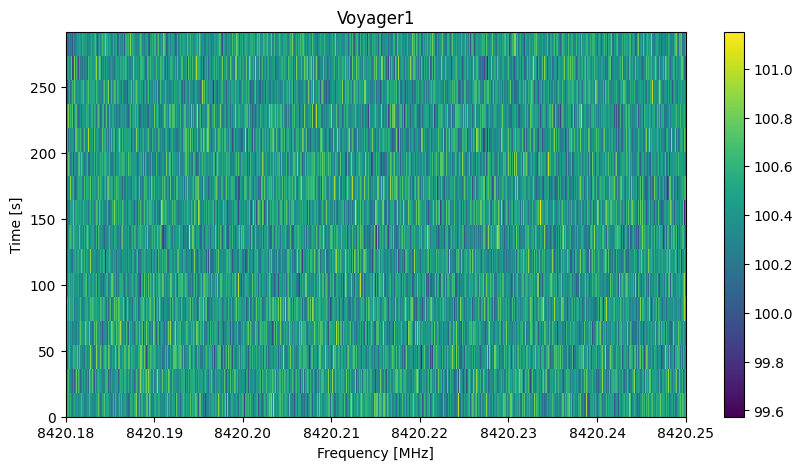

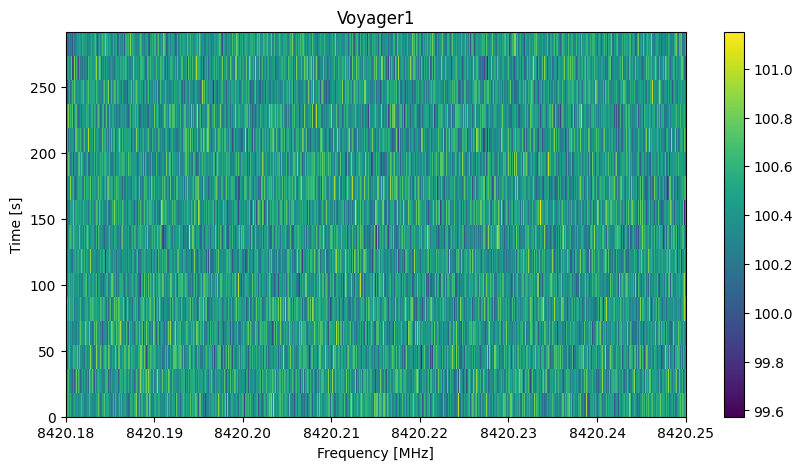

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(10, 5))
fil.plot_waterfall(f_start=8420.18, f_stop=8420.25)
plt.show()

In [6]:
from src.data.real import *

chunk_observation(
    repo_root / "data/raw/Voyager1.single_coarse.fine_res.h5",
    out_dir=str(repo_root / "data/processed/real"),
)

Saved 256 frames of shape (16, 4096) to /Users/parthshringarpure/projects/SETI/DeepSeti/data/processed/real


In [7]:
import numpy as np

real = np.load(repo_root / "data/processed/real/real_00000.npy")
print("shape:", real.shape, "dtype:", real.dtype)
print("min/max:", real.min(), real.max())
print("mean/std:", real.mean(), real.std())

shape: (16, 4096) dtype: float32
min/max: 3.3846252e+09 8.4426634e+09
mean/std: 5.5211315e+09 5.7423194e+08
